# Question 1c

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def max_G(I, epsilon):
    return I + epsilon / np.sqrt(1 + 4 * np.pi**2)

def G(I, epsilon, t):
    return I + epsilon * (np.sin(2 * np.pi * t) - 2 * np.pi * np.cos(2 * np.pi * t)) / (1 + 4 * np.pi**2)

def v(I, epsilon, t, T_n):
    return G(I, epsilon, t) - G(I, epsilon, T_n) * np.exp(-(t - T_n))

def find_first_spike_time_interval_end(I, epsilon, T_n, dt):
    if max_G(I, epsilon) <= 1: return None

    t = T_n
    while True:
        if v(I, epsilon, t, T_n) > 1: return t
        t += dt

def find_first_spike_time(I, epsilon, T_n, dt, tolerance = 1e-6):
    right = find_first_spike_time_interval_end(I, epsilon, T_n, dt)
    if right is None: return None
    left = right - dt

    while (right - left) > tolerance:
        mid = (left + right) / 2
        if v(I, epsilon, mid, T_n) > 1:
            right = mid
        else:
            left = mid

    return left

def lif(I, epsilon, T, dt):
    T_n = 0
    spikes = np.array([])
    phases = np.array([])
    while T_n <= T:
        T_n_plus_1 = find_first_spike_time(I, epsilon, T_n, dt)
        if T_n_plus_1 is None: return (0, None)

        # Only start counting when not transient
        if T_n_plus_1 > T / 10:
            spikes = np.append(spikes, T_n_plus_1)
            phases = np.append(phases, T_n_plus_1 % 1)

        T_n = T_n_plus_1

    spike_rate = len(spikes[:-1]) / (T - (T / 10))
    phase = np.mean(phases)

    return spike_rate, phase

In [3]:
spike_rates = []
unforced_spike_rates = []

for i, I in enumerate(np.linspace(0.9, 3, 1000)):
    spike_rate, phase = lif(I = I, epsilon = 0.5, T = 1000, dt = 0.025)
    spike_rates.append(spike_rate)
    if I <= 1:
        unforced_spike_rates.append(0)
    else:
        unforced_spike_rates.append(1 / np.log(I / (I - 1)))

    if i > 0 and spike_rates[i - 1] == spike_rates[i]:
        print(f"Plateau Spike Rate: {spike_rates[i]}")

Plateau Spike Rate: 0
Plateau Spike Rate: 0
Plateau Spike Rate: 0
Plateau Spike Rate: 0
Plateau Spike Rate: 0
Plateau Spike Rate: 0
Plateau Spike Rate: 0
Plateau Spike Rate: 0
Plateau Spike Rate: 0
Plateau Spike Rate: 0
Plateau Spike Rate: 0.16666666666666666
Plateau Spike Rate: 0.2
Plateau Spike Rate: 0.2
Plateau Spike Rate: 0.2
Plateau Spike Rate: 0.2
Plateau Spike Rate: 0.25
Plateau Spike Rate: 0.25
Plateau Spike Rate: 0.25
Plateau Spike Rate: 0.25
Plateau Spike Rate: 0.25
Plateau Spike Rate: 0.25
Plateau Spike Rate: 0.25
Plateau Spike Rate: 0.25
Plateau Spike Rate: 0.25
Plateau Spike Rate: 0.25
Plateau Spike Rate: 0.25
Plateau Spike Rate: 0.28555555555555556
Plateau Spike Rate: 0.3333333333333333
Plateau Spike Rate: 0.3333333333333333
Plateau Spike Rate: 0.3333333333333333
Plateau Spike Rate: 0.3333333333333333
Plateau Spike Rate: 0.3333333333333333
Plateau Spike Rate: 0.3333333333333333
Plateau Spike Rate: 0.3333333333333333
Plateau Spike Rate: 0.3333333333333333
Plateau Spike Rat

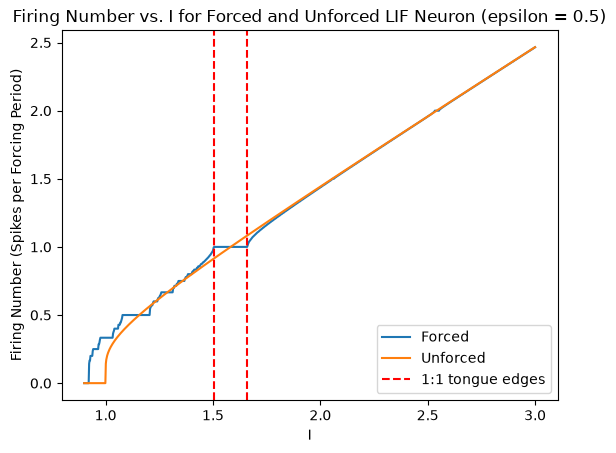

In [4]:
plt.plot(np.linspace(0.9, 3, 1000), spike_rates, label = "Forced")
plt.plot(np.linspace(0.9, 3, 1000), unforced_spike_rates, label = "Unforced")
plt.axvline(-0.5/(np.sqrt(1 + 4 * np.pi**2)) + 1/(1 - np.exp(-1)), color = "red", linestyle = "--", label = "1:1 tongue edges")
plt.axvline(0.5/(np.sqrt(1 + 4 * np.pi**2)) + 1/(1 - np.exp(-1)), color = "red", linestyle = "--")

plt.xlabel("I")
plt.ylabel("Firing Number (Spikes per Forcing Period)")
plt.title("Firing Number vs. I for Forced and Unforced LIF Neuron (epsilon = 0.5)")

plt.legend()
plt.show()

In [5]:
spike_rate, phase = lif(I = 1.6, epsilon = 0.5, T = 1000, dt = 0.025)
print(f"Spike Rate: {spike_rate}, Phase: {phase}")

Spike Rate: 1.0, Phase: 0.1880500791038638


# Question 2c

In [6]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [7]:
def compute_delta(tau, I, v_r, v_th):
    return tau * np.log((I * tau - v_r) / (I * tau - v_th))

def get_T_prime(phi, tau = 1, I = 1.5, v_r = 0, v_th = 1, kick = 1e-3):
    delta = compute_delta(tau, I, v_r, v_th)

    if phi == 0: v = v_r
    else:
        solution = solve_ivp(
            fun = lambda t, y: -y[0] / tau + I, 
            t_span = [0, phi * delta],
            y0 = [v_r],
            rtol = 1e-10,
            atol = 1e-12
        )

        v = solution.y[0][-1] + kick
        if v >= v_th:
            return phi * delta

    solution = solve_ivp(
        fun = lambda t, y: -y[0] / tau + I, 
        t_span = [phi * delta,  phi * delta + 10],
        y0 = [v],
        events = lambda t, y: y[0] - v_th,
        rtol = 1e-10,
        atol = 1e-12
    )

    return solution.t_events[0][0]

def compute_R(phi, tau = 1, I = 1.5, v_r = 0, v_th = 1, kick = 1e-3):
    delta = compute_delta(tau, I, v_r, v_th)
    T_prime = get_T_prime(phi, tau, I, v_r, v_th, kick)
    return (delta - T_prime) / (delta * kick)

def compute_R_formula(phi, tau = 1, I = 1.5, v_r = 0, v_th = 1, kick = 1e-3):
    delta = compute_delta(tau, I, v_r, v_th)
    return (tau * np.exp(phi * delta / tau)) / (delta * (I * tau - v_r))

Max R Difference: 0.0017836486751330316


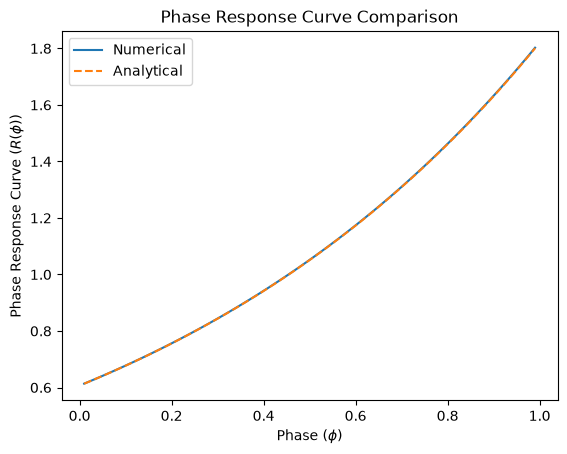

In [ ]:
phis = np.linspace(0, 1, 101, endpoint = False)[1:] # Ignore phi = 0
R_values = [compute_R(phi) for phi in phis]
R_formula_values = [compute_R_formula(phi) for phi in phis]

print("Max R Difference:", np.max(np.abs(np.array(R_values) - np.array(R_formula_values))))

plt.plot(phis, R_values, label = "Numerical")
plt.plot(phis, R_formula_values, label = "Analytical", linestyle = "--")

plt.xlabel("Phase ($\\phi$)")
plt.ylabel("Phase Response Curve ($R(\\phi)$)")
plt.title("Phase Response Curve Comparison")

plt.legend()
plt.show()

In [9]:
def rhs(t, y):
    return [y[0] - y[0]**3 / 3 - y[1] + 0.5, 0.08 * (y[0] + 0.7 - 0.8 * y[1])]

def up_cross(t, y):
    return y[0] - 0.0
up_cross.direction = 1

def find_period(T_total = 5000):
    solution = solve_ivp(
        fun = rhs,
        t_span = [0, T_total],
        y0 = [0, 0],
        events = up_cross,
        rtol = 1e-10,
        atol = 1e-12
    )

    t_cross = solution.t_events[0]
    y_cross = solution.y_events[0]
    periods = np.diff(t_cross)
    delta = np.mean(periods[1:]) # Ignore first period as transient
    y0 = y_cross[-1]

    return delta, y0, periods

def FHN_crossings(phi, delta, y0, kick = 1e-3, n = 5):
    if phi == 0: v, w = y0
    else:
        solution = solve_ivp(
            fun = rhs, 
            t_span = [0, phi * delta],
            y0 = y0,
            rtol = 1e-10,
            atol = 1e-12
        )

        v, w = solution.y[:, -1]

    solution = solve_ivp(
        fun = rhs, 
        t_span = [phi * delta, (n + 1) * delta],
        y0 = [v + kick, w],
        events = up_cross,
        rtol = 1e-10,
        atol = 1e-12
    )

    return solution.t_events[0]

def FHN_compute_R(phi, delta, y0, kick = 1e-3, n = 5):
    t_cross = FHN_crossings(phi, delta, y0, kick, n)
    T_n = t_cross[np.argmin(np.abs(t_cross - n * delta))]
    return (n *delta - T_n) / (delta * kick)

Delta: 39.474414980139436
Max R: 0.28468366683586765 Location: 0.895
Min R: -0.11804590821330396 Location: 0.305
Phis for R < 0: [0.22  0.225 0.23  0.235 0.24  0.245 0.25  0.255 0.26  0.265 0.27  0.275
 0.28  0.285 0.29  0.295 0.3   0.305 0.31  0.315 0.32  0.325 0.33  0.335
 0.34  0.345 0.35  0.355 0.36  0.365 0.37  0.375 0.38  0.385 0.39  0.395
 0.4   0.405 0.41  0.415 0.42  0.425 0.43  0.435 0.44  0.445 0.45  0.455
 0.46  0.465 0.47  0.475 0.48  0.485 0.49  0.495 0.5   0.505 0.51  0.515
 0.52  0.525 0.53  0.535 0.54  0.545 0.55  0.555 0.56  0.565 0.57  0.575
 0.58  0.585 0.59  0.595 0.6   0.605 0.61  0.615 0.62  0.625 0.63  0.635
 0.64  0.645 0.65  0.655 0.66  0.665 0.67  0.675 0.68  0.685 0.69  0.695
 0.7   0.705 0.71  0.715 0.72  0.725 0.73  0.735 0.74  0.745 0.75  0.755
 0.76  0.765 0.77  0.775 0.78  0.785 0.79  0.795]


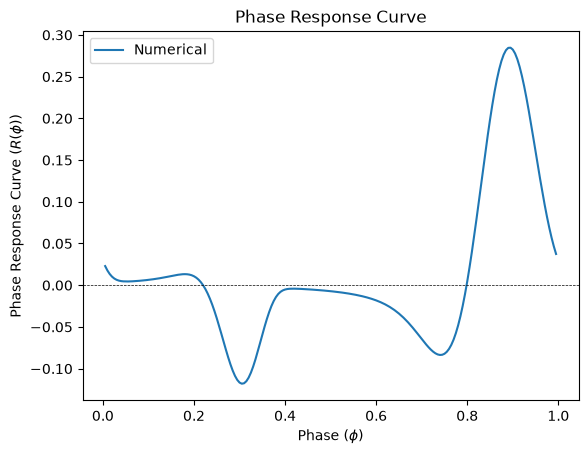

In [10]:
delta, y0, _ = find_period()
print("Delta:", delta)
phis = np.linspace(0, 1, 200, endpoint = False)[1:] # Ignore phi = 0
R_values = [FHN_compute_R(phi, delta, y0) for phi in phis]

print("Max R:", np.max(R_values), "Location:", phis[np.argmax(R_values)])
print("Min R:", np.min(R_values), "Location:", phis[np.argmin(R_values)])
print("Phis for R < 0:", phis[np.where(np.array(R_values) < 0)])

plt.plot(phis, R_values, label = "Numerical")
plt.axhline(0, color = "black", linestyle = "--", linewidth = 0.5)

plt.xlabel("Phase ($\\phi$)")
plt.ylabel("Phase Response Curve ($R(\\phi)$)")
plt.title("Phase Response Curve")

plt.legend()
plt.show()

# Question 4c

In [11]:
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt

In [12]:
def rhs(t, v, epsilon, L):
    return [
        1 + v[0]**2 + epsilon *(v[1] - v[0]),
        1 + v[1]**2 + epsilon *(v[0] - v[1])
    ]

def neuron_1_spike(t, v, epsilon, L):
    return v[0] - L
neuron_1_spike.terminal = True
neuron_1_spike.direction = 1

def neuron_2_spike(t, v, epsilon, L):
    return v[1] - L
neuron_2_spike.terminal = True
neuron_2_spike.direction = 1

def simulate(epsilon, L, v0 , t_max):
    t = 0
    v = v0

    neuron_1_spike_times = []
    neuron_2_spike_times = []

    while t < t_max:
        solution = solve_ivp(
            fun = rhs,
            t_span = [t, t_max],
            y0 = v,
            method = "DOP853",
            events = [neuron_1_spike, neuron_2_spike],
            args = (epsilon, L),
            rtol = 1e-10,
            atol = 1e-10
        )

        if solution.t_events[0].size > 0: # If neuron 1 spikes first
            neuron_1_spike_times.append(solution.t_events[0][0])
            t = solution.t_events[0][0]
            v = [-L, solution.y[1][-1]]
        elif solution.t_events[1].size > 0: # If neuron 2 spikes first
            neuron_2_spike_times.append(solution.t_events[1][0])
            t = solution.t_events[1][0]
            v = [solution.y[0][-1], -L]
        else:
            break

    return np.array(neuron_1_spike_times), np.array(neuron_2_spike_times)

def measure_lag(t1, t2):
    t_k = []
    phi_k = []
    for k in range(len(t1) - 1):
        if t1[k] > t2[-1]: break
        t_k.append(t1[k])
        t2_k = t2[np.searchsorted(t2, t1[k])]
        phi_k.append((t2_k - t1[k]) / (t1[k + 1] - t1[k]))

    return np.array(t_k), np.array(phi_k)


In [13]:
neuron_1_spike_times, neuron_2_spike_times = simulate(epsilon = 0.02, L = 200, v0 = [-200, -1/np.tan(0.6*np.pi)], t_max = 300)
t_k, phi_k = measure_lag(neuron_1_spike_times, neuron_2_spike_times)
predicted_phi = np.arctan(np.tan(np.pi * 0.4) * np.exp(-2 * 0.02 * t_k)) / np.pi

Max Absolute Phase Lag Difference: 0.062849187271459


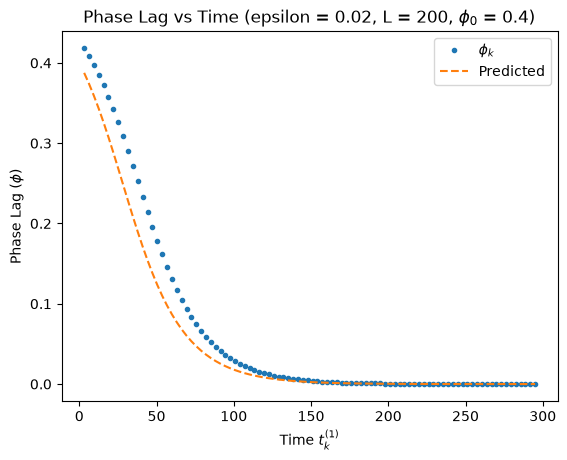

In [14]:
print("Max Absolute Phase Lag Difference:", np.max(np.abs(np.array(phi_k) - np.array(predicted_phi))))

plt.plot(t_k, phi_k, label = "$\\phi_k$", marker = "o", markersize = 3, linestyle = "")
plt.plot(t_k, predicted_phi, label = "Predicted", linestyle = "--")

plt.xlabel("Time $t_k^{(1)}$")
plt.ylabel("Phase Lag ($\\phi$)")
plt.title("Phase Lag vs Time (epsilon = 0.02, L = 200, $\\phi_0$ = 0.4)")

plt.legend()
plt.show();

In [15]:
print("Epsilon | Fitted Slope | 2 * Epsilon | Ratio")
for epsilon, t_max in [(0.005, 1000), (0.02, 300), (0.05, 150)]:
    neuron_1_spike_times, neuron_2_spike_times = simulate(epsilon = epsilon, L = 200, v0 = [-200, -1/np.tan(0.6*np.pi)], t_max = t_max)
    t_k, phi_k = measure_lag(neuron_1_spike_times, neuron_2_spike_times)
    y_k = np.log(np.abs(np.tan(np.pi * phi_k)))
    mask = np.exp(y_k) > 1e-6
    mask[0] = False # Ignore first point as transient
    slope, intercept = np.polyfit(t_k[mask], y_k[mask], 1)
    predicted_phi = np.arctan(np.tan(np.pi * 0.4) * np.exp(-2 * epsilon * t_k)) / np.pi

    print(f"{epsilon:.3f} | {slope:.5f} | {2 * epsilon:.5f} | {slope / (-2 * epsilon):.5f}")

Epsilon | Fitted Slope | 2 * Epsilon | Ratio
0.005 | -0.00986 | 0.01000 | 0.98636
0.020 | -0.03943 | 0.04000 | 0.98565
0.050 | -0.09797 | 0.10000 | 0.97970
